# Tworzenie masek z gotowych segmentacji

## Tworzenie dataframe z danymi

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import imageio.v3 as iio

import subprocess

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [3]:
DATA_PATH_1 = Path("/mnt/d/Backup/INZ/data")
DATA_PATH_2 = Path("/home/ruszczka/projekty/test_files/img")

# ==================== DATASET 1 ====================
# Folder z obrazami (jeśli istnieje)
image_folder_1 = Path(DATA_PATH_1 / "2011_img")

# Funkcje zwracające ścieżki do obrazów dla dataset 1
def get_color_path_1(row):
    return image_folder_1 / f"rlm_rosbag_2024_12_06-10_27_18_{int(row['id'])}_color_orig.png"

def get_blue_path_1(row):
    return image_folder_1 / f"rlm_rosbag_2024_12_06-10_27_18_{int(row['id'])}_finger_blue.png"

def get_red_path_1(row):
    return image_folder_1 / f"rlm_rosbag_2024_12_06-10_27_18_{int(row['id'])}_finger_green.png"

def get_green_path_1(row):
    return image_folder_1 / f"rlm_rosbag_2024_12_06-10_27_18_{int(row['id'])}_hand_base.png"

csv_file_1 = DATA_PATH_1 / "2011_data.csv"

df_1 = pd.read_csv(csv_file_1, sep=';')[['id']].copy()  # Załaduj tylko kolumnę 'id'

# Dodanie kolumn z ścieżkami
df_1['color_path'] = df_1.apply(get_color_path_1, axis=1)
df_1['blue_path'] = df_1.apply(get_blue_path_1, axis=1)
df_1['red_path'] = df_1.apply(get_red_path_1, axis=1)
df_1['green_path'] = df_1.apply(get_green_path_1, axis=1)

# ==================== DATASET 2 ====================
# Foldery z obrazami
image_folder_2a = Path(DATA_PATH_2 / "icm_111")
image_folder_2b = Path(DATA_PATH_2 / "icm_61")

# Funkcje zwracające ścieżki dla dataset 2a (icm_111)
def get_color_path_2a(row):
    return image_folder_2a / f"imitation_control_model_2025_03_25-14_39_50_{int(row['id'])}_color_orig.png"

def get_blue_path_2a(row):
    return image_folder_2a / f"imitation_control_model_2025_03_25-14_39_50_{int(row['id'])}_finger_blue.png"

def get_red_path_2a(row):
    return image_folder_2a / f"imitation_control_model_2025_03_25-14_39_50_{int(row['id'])}_finger_green.png"

def get_green_path_2a(row):
    return image_folder_2a / f"imitation_control_model_2025_03_25-14_39_50_{int(row['id'])}_hand_base.png"

# Funkcje zwracające ścieżki dla dataset 2b (icm_61)
def get_color_path_2b(row):
    return image_folder_2b / f"imitation_control_model_2024_12_03-12_31_55_{int(row['id'])}_color_orig.png"

def get_blue_path_2b(row):
    return image_folder_2b / f"imitation_control_model_2024_12_03-12_31_55_{int(row['id'])}_finger_blue.png"

def get_red_path_2b(row):
    return image_folder_2b / f"imitation_control_model_2024_12_03-12_31_55_{int(row['id'])}_finger_green.png"

def get_green_path_2b(row):
    return image_folder_2b / f"imitation_control_model_2024_12_03-12_31_55_{int(row['id'])}_hand_base.png"

# Załadowanie DataFramów z CSV
csv_file_2a = image_folder_2a / "imitation_control_model_2025_03_25-14_39_50.csv"
csv_file_2b = image_folder_2b / "imitation_control_model_2024_12_03-12_31_55.csv"

df_2a = pd.read_csv(csv_file_2a, sep=' ')[['id']].copy()  # Załaduj tylko kolumnę 'id'
df_2b = pd.read_csv(csv_file_2b, sep=' ')[['id']].copy()

# Dodanie kolumn z ścieżkami do df_2a
df_2a['color_path'] = df_2a.apply(get_color_path_2a, axis=1)
df_2a['blue_path'] = df_2a.apply(get_blue_path_2a, axis=1)
df_2a['red_path'] = df_2a.apply(get_red_path_2a, axis=1)
df_2a['green_path'] = df_2a.apply(get_green_path_2a, axis=1)

# Dodanie kolumn z ścieżkami do df_2b
df_2b['color_path'] = df_2b.apply(get_color_path_2b, axis=1)
df_2b['blue_path'] = df_2b.apply(get_blue_path_2b, axis=1)
df_2b['red_path'] = df_2b.apply(get_red_path_2b, axis=1)
df_2b['green_path'] = df_2b.apply(get_green_path_2b, axis=1)

# Połączenie DataFrameów (dodaj kolumnę source aby wiedzieć skąd pochodzą dane)
df_2a['source'] = 'icm_111'
df_2b['source'] = 'icm_61'
df_2 = pd.concat([df_2a, df_2b], ignore_index=True)

print(f"Dataset 1: {len(df_1)} zdjęć\nDataset 2: {len(df_2)} zdjęć")

Dataset 1: 2012 zdjęć
Dataset 2: 172 zdjęć


In [22]:
df_1.head()

,id,color_path,blue_path,red_path,green_path
0,0,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_0_color_orig.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_0_finger_blue.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_0_finger_green.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_0_hand_base.png
1,1,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_1_color_orig.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_1_finger_blue.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_1_finger_green.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_1_hand_base.png
2,2,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_2_color_orig.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_2_finger_blue.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_2_finger_green.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_2_hand_base.png
3,3,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_3_color_orig.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_3_finger_blue.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_3_finger_green.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_3_hand_base.png
4,4,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_4_color_orig.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_4_finger_blue.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_4_finger_green.png,/mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_2024_12_06-10_27_18_4_hand_base.png


In [23]:
df_2.head()

,id,color_path,blue_path,red_path,green_path,source
0,0,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_0_color_orig.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_0_finger_blue.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_0_finger_green.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_0_hand_base.png,icm_111
1,1,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_1_color_orig.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_1_finger_blue.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_1_finger_green.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_1_hand_base.png,icm_111
2,2,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_2_color_orig.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_2_finger_blue.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_2_finger_green.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_2_hand_base.png,icm_111
3,3,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_3_color_orig.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_3_finger_blue.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_3_finger_green.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_3_hand_base.png,icm_111
4,4,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_4_color_orig.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_4_finger_blue.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_4_finger_green.png,/home/ruszczka/projekty/test_files/img/icm_111/imitation_control_model_2025_03_25-14_39_50_4_hand_base.png,icm_111


## Przekształcenie masek na prostokąty

In [10]:
def mask_to_bbox_normalized(red_path, green_path, blue_path):
    """Konwertuje maski na normalized xyxy bounding boxy w formacie (red, green, blue)"""
    bboxes = []
    image_shape = None
    
    for mask_path in [red_path, green_path, blue_path]:
        if not Path(mask_path).exists():
            bboxes.append([0.0, 0.0, 0.0, 0.0])
            continue
            
        mask = iio.imread(mask_path)
        if mask.ndim == 3:
            mask = mask[..., 0]
        
        # Zapisz wymiary obrazu z pierwszej maski
        if image_shape is None:
            image_shape = mask.shape  # (height, width)
        
        ys, xs = np.where(mask > 0)
        if xs.size == 0:
            bboxes.append([0.0, 0.0, 0.0, 0.0])
            continue
        
        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        
        # Normalizacja względem wymiarów obrazu
        height, width = image_shape
        x_min_norm = float(x_min) / width
        y_min_norm = float(y_min) / height
        x_max_norm = float(x_max) / width
        y_max_norm = float(y_max) / height
        
        bboxes.append([x_min_norm, y_min_norm, x_max_norm, y_max_norm])
    
    return np.array(bboxes, dtype=np.float32).flatten()  # (12,) - red, green, blue flattened

# Test na jednym rekordzie z niepustą maską
test_row = df_1.iloc[test_idx]
bbox_array = mask_to_bbox_normalized(test_row['red_path'], test_row['green_path'], test_row['blue_path'])
print(f"Shape: {bbox_array.shape}")
print(f"Bboxes (red, green, blue) xyxy normalized:")
print(f"Red:   {bbox_array[0:4]}")
print(f"Green: {bbox_array[4:8]}")
print(f"Blue:  {bbox_array[8:12]}")

Shape: (12,)
Bboxes (red, green, blue) xyxy normalized:
Red:   [0.4140625  0.3443396  0.47460938 0.43396226]
Green: [0.50390625 0.31839624 0.5605469  0.39150944]
Blue:  [0.47265625 0.4033019  0.52734375 0.48349056]


In [32]:
df_1.columns

Index(['id', 'color_path', 'blue_path', 'red_path', 'green_path',
       'blue_path_bbox', 'red_path_bbox', 'green_path_bbox'],
      dtype='object')

### df_1

In [41]:
# Tworzenie pełnej tablicy (len(df_1), 12)
bboxes_array_1 = np.zeros((len(df_1), 12), dtype=np.float32)

for idx in range(len(df_1)):
    row = df_1.iloc[idx]
    bboxes_array_1[idx] = mask_to_bbox_normalized(row['red_path'], row['green_path'], row['blue_path'])
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(df_1)} images")

print(f"\nFinal array shape: {bboxes_array_1.shape}")
print(f"Sample bbox (index 11): {bboxes_array_1[11]}")

# Zapisanie do outputs
output_path = Path('/home/ruszczka/projekty/test_files/outputs')
output_path.mkdir(parents=True, exist_ok=True)
np.save(output_path / 'bboxes_normalized_1.npy', bboxes_array_1)
print(f"\nSaved to {output_path / 'bboxes_normalized_1.npy'}")

Processed 100/2012 images
Processed 200/2012 images
Processed 300/2012 images
Processed 400/2012 images
Processed 500/2012 images
Processed 600/2012 images
Processed 700/2012 images
Processed 800/2012 images
Processed 900/2012 images
Processed 1000/2012 images
Processed 1100/2012 images
Processed 1200/2012 images
Processed 1300/2012 images
Processed 1400/2012 images
Processed 1500/2012 images
Processed 1600/2012 images
Processed 1700/2012 images
Processed 1800/2012 images
Processed 1900/2012 images
Processed 2000/2012 images

Final array shape: (2012, 12)
Sample bbox (index 11): [0.43554688 0.3726415  0.45117188 0.43396226 0.4453125  0.3231132
 0.49804688 0.3561321  0.49414062 0.3773585  0.51171875 0.44103774]

Saved to /home/ruszczka/projekty/test_files/outputs/bboxes_normalized_1.npy


### df_2

In [11]:
# Tworzenie pełnej tablicy (len(df_2), 12)
bboxes_array_2 = np.zeros((len(df_2), 12), dtype=np.float32)

for idx in range(len(df_2)):
    row = df_2.iloc[idx]
    bboxes_array_2[idx] = mask_to_bbox_normalized(row['red_path'], row['green_path'], row['blue_path'])
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(df_2)} images")

print(f"\nFinal array shape: {bboxes_array_2.shape}")
print(f"Sample bbox (index 11): {bboxes_array_2[11]}")

# Zapisanie do outputs
output_path = Path('/home/ruszczka/projekty/test_files/outputs')
output_path.mkdir(parents=True, exist_ok=True)
np.save(output_path / 'bboxes_normalized_2.npy', bboxes_array_2)
print(f"\nSaved to {output_path / 'bboxes_normalized_2.npy'}")

Processed 100/172 images

Final array shape: (172, 12)
Sample bbox (index 11): [0.5449219  0.2806604  0.5761719  0.33490565 0.5546875  0.254717
 0.59765625 0.28537735 0.6171875  0.2759434  0.6582031  0.3561321 ]

Saved to /home/ruszczka/projekty/test_files/outputs/bboxes_normalized_2.npy


In [6]:
bboxes_array_1 = np.load('outputs/bboxes_normalized_1.npy')
print(f"Loaded array shape: {bboxes_array_1.shape}")
print(f"Sample bbox (index 11): {bboxes_array_1[11]}")

Loaded array shape: (2012, 12)
Sample bbox (index 11): [0.43554688 0.3726415  0.45117188 0.43396226 0.4453125  0.3231132
 0.49804688 0.3561321  0.49414062 0.3773585  0.51171875 0.44103774]


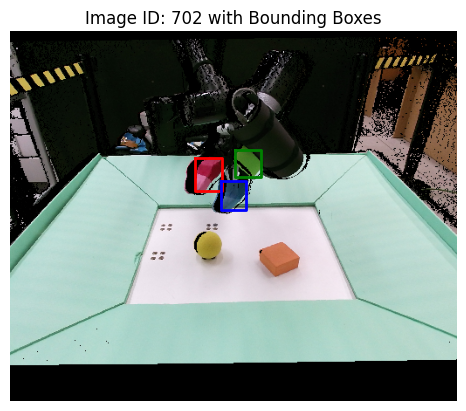

In [7]:
# wiuzalizacja na jednym przykładzie
import matplotlib.pyplot as plt

test_idx = 702
test_row = df_1.iloc[test_idx]
color_image = iio.imread(test_row['color_path'])

# rysowanie boxów na obrazie z wykorzystaniem bbox_array_1[test_idx]
bbox_array = bboxes_array_1[test_idx].reshape(3, 4)  # (3, 4) - red, green, blue
colors = ['red', 'green', 'blue']
plt.imshow(color_image)
for i in range(3):
    x_min, y_min, x_max, y_max = bbox_array[i]
    height, width, _ = color_image.shape
    x_min_pixel = int(x_min * width)
    y_min_pixel = int(y_min * height)
    x_max_pixel = int(x_max * width)
    y_max_pixel = int(y_max * height)
    
    plt.plot([x_min_pixel, x_max_pixel, x_max_pixel, x_min_pixel, x_min_pixel],
             [y_min_pixel, y_min_pixel, y_max_pixel, y_max_pixel, y_min_pixel],
             color=colors[i], linewidth=2)
plt.title(f"Image ID: {test_row['id']} with Bounding Boxes")
plt.axis('off')
plt.show()

## Pokazanie obrazów, na których pracuje

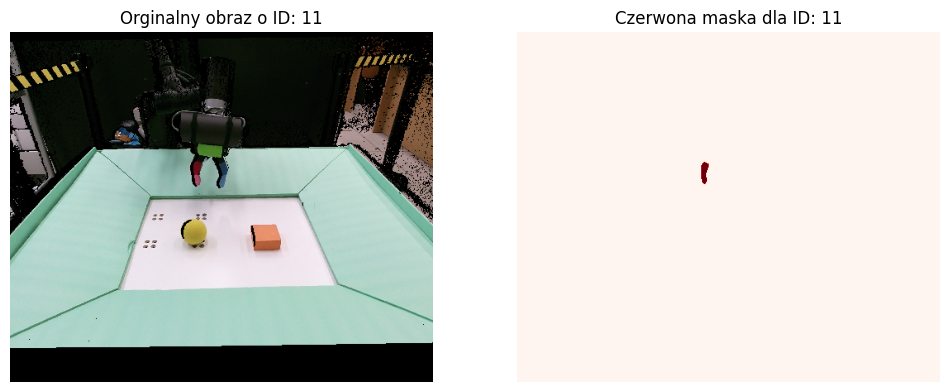

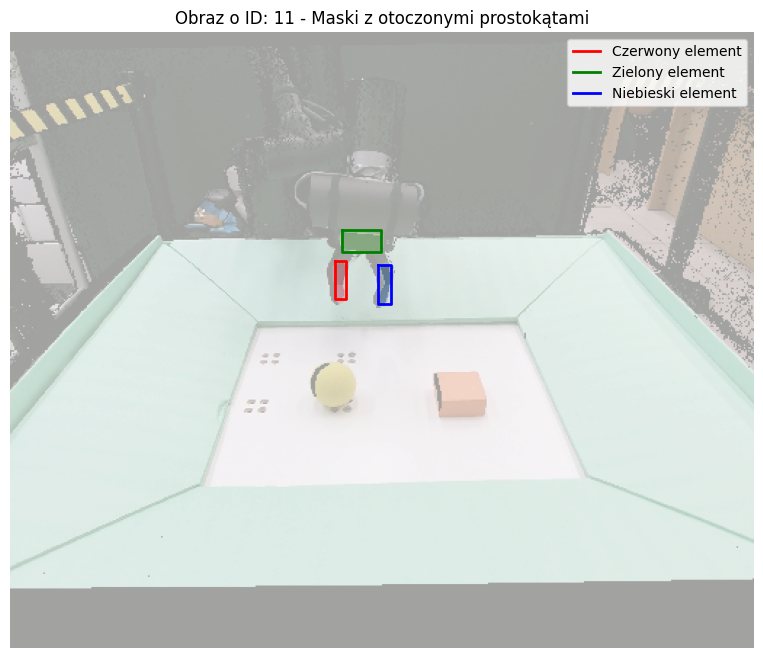

In [ ]:
test_idx = 11
test_row = df_1.iloc[test_idx]

# plot orginalnego obrazu i obok obraz czerwonej maski
color_image = iio.imread(test_row['color_path'])
red_mask = iio.imread(test_row['red_path'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(color_image)
plt.title(f"Orginalny obraz o ID: {test_row['id']}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(red_mask, cmap='Reds')
plt.title(f"Czerwona maska dla ID: {test_row['id']}")
plt.axis('off')
plt.show()

# Wyświetlanie masek i boxów na jednym obrazie
color_image = iio.imread(test_row['color_path'])
red_mask = iio.imread(test_row['red_path'])
green_mask = iio.imread(test_row['green_path'])
blue_mask = iio.imread(test_row['blue_path'])

# Normalizacja masek do zakresu 0-1
if red_mask.ndim == 3:
    red_mask = red_mask[..., 0]
if green_mask.ndim == 3:
    green_mask = green_mask[..., 0]
if blue_mask.ndim == 3:
    blue_mask = blue_mask[..., 0]

red_mask = red_mask.astype(float) / 255.0
green_mask = green_mask.astype(float) / 255.0
blue_mask = blue_mask.astype(float) / 255.0

# Tworzenie obrazu z nałożonymi maskami
plt.figure(figsize=(12, 8))
plt.imshow(color_image)

# Nałożenie masek z przezroczystością
plt.imshow(red_mask, cmap='Reds', alpha=0.3)
plt.imshow(green_mask, cmap='Greens', alpha=0.3)
plt.imshow(blue_mask, cmap='Blues', alpha=0.3)

# Rysowanie bounding boxów
bbox_array = bboxes_array_1[test_idx].reshape(3, 4)
colors = ['red', 'green', 'blue']
kolory = ['Czerwony', 'Zielony', 'Niebieski']
height, width, _ = color_image.shape

for i, color in enumerate(colors):
    x_min, y_min, x_max, y_max = bbox_array[i]
    x_min_pixel = int(x_min * width)
    y_min_pixel = int(y_min * height)
    x_max_pixel = int(x_max * width)
    y_max_pixel = int(y_max * height)
    
    plt.plot([x_min_pixel, x_max_pixel, x_max_pixel, x_min_pixel, x_min_pixel],
             [y_min_pixel, y_min_pixel, y_max_pixel, y_max_pixel, y_min_pixel],
             color=color, linewidth=2, label=f'{kolory[i]} element')

plt.title(f"Obraz o ID: {test_row['id']} - Maski z otoczonymi prostokątami")
plt.legend()
plt.axis('off')
plt.show()